In [1]:
# ==============================================================
# ЯЧЕЙКА 157
# ==============================================================
import numpy as np
import math
 
# ── Функции принадлежности (общие для всех трёх регуляторов) ──
def trapmf(x, a, b, c, d):
    x = float(x)
    if x <= a or x >= d: return 0.0
    if b <= x <= c:      return 1.0
    if x < b:            return (x - a) / (b - a) if b > a else 1.0
    return (d - x) / (d - c) if d > c else 1.0
 
def trimf(x, a, b, c):
    x = float(x)
    if x <= a or x >= c: return 0.0
    if x < b:            return (x - a) / (b - a) if b > a else 1.0
    return (c - x) / (c - b) if c > b else 1.0
 
# Функции принадлежности переменной D (TTR)
D_MF = {
    "Low":    lambda x: trapmf(x, 0.00, 0.00, 0.20, 0.40),
    "Medium": lambda x: trimf (x, 0.25, 0.50, 0.75),
    "High":   lambda x: trapmf(x, 0.60, 0.80, 1.00, 1.00),
}
 
# Функции принадлежности переменной H (энтропия)
H_MF = {
    "Low":    lambda x: trapmf(x, 0.00, 0.00, 0.20, 0.40),
    "Medium": lambda x: trimf (x, 0.25, 0.50, 0.75),
    "High":   lambda x: trapmf(x, 0.60, 0.80, 1.00, 1.00),
}
 
def fuzzify(d_val, h_val):
    """
    Единый блок фаззификации для регуляторов τ* и β*.
    Вычисляется один раз и передаётся обоим регуляторам.
    Возвращает словари степеней принадлежности mu_d и mu_h.
    """
    mu_d = {k: f(d_val) for k, f in D_MF.items()}
    mu_h = {k: f(h_val) for k, f in H_MF.items()}
    return mu_d, mu_h
 
print("Блок фаззификации определён.")
print(f"Тест fuzzify(0.5, 0.5):")
mu_d, mu_h = fuzzify(0.5, 0.5)
print(f"  mu_d = {mu_d}")
print(f"  mu_h = {mu_h}")

Блок фаззификации определён.
Тест fuzzify(0.5, 0.5):
  mu_d = {'Low': 0.0, 'Medium': 1.0, 'High': 0.0}
  mu_h = {'Low': 0.0, 'Medium': 1.0, 'High': 0.0}


In [2]:
# ==============================================================
# ЯЧЕЙКА 158
# ==============================================================
# Диапазон τ* ∈ [0.5, 3.0], стандарт √d_k ≈ 1.41
N_GRID = 1000
X_TAU = np.linspace(0.5, 3.0, N_GRID)
 
TAU_MF = {
    "Low":    lambda x: trapmf(x, 0.50, 0.50, 0.80, 1.10),
    "Medium": lambda x: trimf (x, 0.90, 1.41, 1.90),
    "High":   lambda x: trapmf(x, 1.70, 2.20, 3.00, 3.00),
}
 
# База правил регулятора τ* (раздел 2.6)
RULES_TAU = [
    ("High",   "Low",    "Low"),
    ("High",   "Medium", "Low"),
    ("High",   "High",   "Medium"),
    ("Medium", "Low",    "Low"),
    ("Medium", "Medium", "Medium"),
    ("Medium", "High",   "High"),
    ("Low",    "Low",    "Medium"),
    ("Low",    "Medium", "High"),
    ("Low",    "High",   "High"),
]
 
def infer_tau(mu_d, mu_h):
    """
    Нечёткий вывод τ* по готовым mu_d, mu_h из fuzzify().
    Принимает результат fuzzify() — не пересчитывает фаззификацию.
    """
    agg = np.zeros(N_GRID)
    for d_t, h_t, tau_t in RULES_TAU:
        w = min(mu_d[d_t], mu_h[h_t])
        cut = np.minimum(w, np.array([TAU_MF[tau_t](x) for x in X_TAU]))
        agg = np.maximum(agg, cut)
    denom = np.trapz(agg, X_TAU)
    return float(np.trapz(X_TAU * agg, X_TAU) / denom) if denom > 1e-10 else 1.41
 
print("Регулятор τ* определён.")
print(f"Тест infer_tau при D=0.5, H=0.5:")
mu_d, mu_h = fuzzify(0.5, 0.5)
tau = infer_tau(mu_d, mu_h)
print(f"  τ* = {tau:.4f}  (стандарт √2 = {math.sqrt(2):.4f})")

Регулятор τ* определён.
Тест infer_tau при D=0.5, H=0.5:
  τ* = 1.4033  (стандарт √2 = 1.4142)


In [3]:
# ==============================================================
# ЯЧЕЙКА 159
# ==============================================================
# Диапазон β* ∈ [0.3, 2.5], стандарт 1.0
X_BETA = np.linspace(0.3, 2.5, N_GRID)
 
BETA_MF = {
    #"Low":    lambda x: trapmf(x, 0.30, 0.30, 0.65, 1.00),
    #"Medium": lambda x: trimf (x, 0.75, 1.00, 1.35),
    #"High":   lambda x: trapmf(x, 1.20, 1.60, 2.50, 2.50),
    "Low":    lambda x: trapmf(x, 0.70, 0.70, 0.85, 1.00),
    "Medium": lambda x: trimf (x, 0.9, 1.20, 1.55),
    "High":   lambda x: trapmf(x, 1.20, 1.60, 2.50, 2.50),
}
 
# База правил регулятора β* (раздел 3.8)
RULES_BETA = [
    ("High",   "Low",    "Low"),
    ("High",   "Medium", "Low"),
    ("High",   "High",   "Medium"),
    ("Medium", "Low",    "Low"),
    ("Medium", "Medium", "Medium"),
    ("Medium", "High",   "High"),
    ("Low",    "Low",    "Medium"),
    ("Low",    "Medium", "High"),
    ("Low",    "High",   "High"),
]
 
def infer_beta(mu_d, mu_h):
    """
    Нечёткий вывод β* по готовым mu_d, mu_h из fuzzify().
    Принимает результат fuzzify() — не пересчитывает фаззификацию.
    """
    agg = np.zeros(N_GRID)
    for d_t, h_t, beta_t in RULES_BETA:
        w = min(mu_d[d_t], mu_h[h_t])
        cut = np.minimum(w, np.array([BETA_MF[beta_t](x) for x in X_BETA]))
        agg = np.maximum(agg, cut)
    denom = np.trapz(agg, X_BETA)
    return float(np.trapz(X_BETA * agg, X_BETA) / denom) if denom > 1e-10 else 1.0
 
print("Регулятор β* определён.")
print(f"Тест infer_beta при D=0.5, H=0.5:")
mu_d, mu_h = fuzzify(0.5, 0.5)
beta = infer_beta(mu_d, mu_h)
print(f"  β* = {beta:.4f}  (стандарт = 1.0)")

Регулятор β* определён.
Тест infer_beta при D=0.5, H=0.5:
  β* = 1.2167  (стандарт = 1.0)


In [4]:
# Ячейка 160. Вспомогательные функции вычисления D и H
import numpy as np
import math

def compute_ttr(token_ids):
    """
    Признак D: TTR сгенерированного контекста.
    Вычисляется по последним window токенам выходной последовательности.
    """
    token_ids = list(token_ids)
    if len(token_ids) == 0:
        return 0.5
    return len(set(token_ids)) / len(token_ids)

def compute_entropy(probas_np):
    """
    Признак H: нормированная энтропия Шеннона вероятностного
    распределения предыдущего шага генерации.
    probas_np: numpy array вероятностей формы [vocab_size]
    """
    p = probas_np[probas_np > 0]
    vocab_size = len(probas_np)
    h = -np.sum(p * np.log(p))
    return float(h / math.log(vocab_size)) if vocab_size > 1 else 0.0

print("Вспомогательные функции D и H определены.")
print(f"Тест compute_ttr([1,2,3,1,2]) = {compute_ttr([1,2,3,1,2]):.3f}  (ожидается 0.600)")

p_uniform = np.ones(10) / 10
p_peaked  = np.zeros(10)
p_peaked[0] = 0.99
p_peaked[1:] = 0.001 / 9
print(f"Тест compute_entropy (равномерное) = {compute_entropy(p_uniform):.4f}  (ожидается 1.0)")
print(f"Тест compute_entropy (острое)      = {compute_entropy(p_peaked):.4f}   (ожидается близко к 0)")

Вспомогательные функции D и H определены.
Тест compute_ttr([1,2,3,1,2]) = 0.600  (ожидается 0.600)
Тест compute_entropy (равномерное) = 1.0000  (ожидается 1.0)
Тест compute_entropy (острое)      = 0.0083   (ожидается близко к 0)


In [5]:
import torch
import torch.nn as nn
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb  = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb  = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        keys    = keys.transpose(1,2)
        values  = values.transpose(1,2)
        queries = queries.transpose(1,2)
        

        attn_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)
        attn_weigths = self.dropout(attn_weights)
        
        context_vec = (attn_weights @ values).transpose(1,2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec

class FeedForward(nn.Module):    
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]), GELU(), nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]),)
    def forward(self,x):
        return self.layers(x)

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean)/torch.sqrt(var+self.eps)
        return self.scale * norm_x + self.shift

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [6]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -context_size:]
            with torch.no_grad():
                logits = model(idx_cond)
            logits = logits[:, -1, :]
            probas = torch.softmax(logits, dim=-1)
            idx_next = torch.argmax(probas, dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=-1)
        return idx

In [7]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(model=model, idx=text_to_token_ids(start_context, tokenizer),
                                 max_new_tokens=10, context_size=GPT_CONFIG_124M["context_length"])
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [8]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond=idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
            
        logits = logits[:, -1, :]
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits/temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [9]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                         "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [10]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1aca6a330d0>)

In [11]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [12]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [13]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [14]:
NEW_CONFIG.update({"context_length": 1024})

In [15]:
NEW_CONFIG.update({"qkv_bias": True})

In [16]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [17]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


In [19]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [20]:
# ==============================================================
# ЯЧЕЙКА 161
# ==============================================================
import torch
import torch.nn as nn
 
class FuzzyLLM(nn.Module):
    """
    Нечётко-логический контроллер языковой модели.
    Обёртка над GPTModel, добавляющая три нечётких регулятора:
      - τ* (раздел 2.6): адаптация коэффициента масштабирования внимания
      - β* (раздел 3.8): адаптация коэффициента избирательности декодирования
    Совместный блок фаззификации вычисляется один раз за шаг.
    """
 
    def __init__(self, gpt_model, window=32):
        """
        gpt_model: обученный или предобученный экземпляр GPTModel
        window: число последних токенов для вычисления TTR (признак D)
        """
        super().__init__()
        self.gpt   = gpt_model
        self.window = window
 
        # Начальные значения регуляторов (нейтральный режим)
        self.tau_star  = math.sqrt(2)  # стандарт раздела 2.6
        self.beta_star = 1.0           # стандарт раздела 3.8
        self.prev_H    = 0.5           # начальная энтропия (нейтральная)
 
        # История регуляторов для анализа (раздел 4.6.6)
        self.history = {
            "D":    [],
            "H":    [],
            "tau":  [],
            "beta": [],
            "step": [],
        }
 
    def forward(self, in_idx):
        """
        Прямой проход через GPTModel.
        Адаптация τ* происходит внутри MultiHeadAttention
        при вызове generate_fuzzy (не здесь).
        """
        return self.gpt(in_idx)
 
    def fuzzy_step(self, context_ids):
        """
        Единый шаг нечёткого контроллера.
        1. Вычисляет D и H
        2. Запускает совместную фаззификацию (один раз)
        3. Параллельно получает τ* и β*
        Возвращает tau_star, beta_star, D, H
        """
        # Признак D: TTR последних window токенов контекста
        ctx = context_ids[0, -self.window:].tolist()
        D = compute_ttr(ctx)
 
        # Признак H: энтропия предыдущего шага
        H = self.prev_H
 
        # СОВМЕСТНАЯ ФАЗЗИФИКАЦИЯ: один вызов для обоих регуляторов
        mu_d, mu_h = fuzzify(D, H)
 
        # Параллельные выводы из одной фаззификации
        tau_star  = infer_tau(mu_d, mu_h)
        beta_star = infer_beta(mu_d, mu_h)
 
        # Обновление состояния
        self.tau_star  = tau_star
        self.beta_star = beta_star
 
        return tau_star, beta_star, D, H
 
    def reset(self):
        """Сброс состояния между независимыми генерациями."""
        self.tau_star  = math.sqrt(2)
        self.beta_star = 1.0
        self.prev_H    = 0.5
        self.history   = {k: [] for k in self.history}
 
print("Класс FuzzyLLM определён.")
 
# Инициализация обёртки поверх модели с весами OpenAI
fuzzy_model = FuzzyLLM(gpt, window=32)
fuzzy_model.to(device)
fuzzy_model.eval()
print(f"FuzzyLLM создан на устройстве: {device}")
print(f"  Начальный τ* = {fuzzy_model.tau_star:.4f}")
print(f"  Начальный β* = {fuzzy_model.beta_star:.4f}")

Класс FuzzyLLM определён.
FuzzyLLM создан на устройстве: cpu
  Начальный τ* = 1.4142
  Начальный β* = 1.0000


In [21]:
def generate_fuzzy(fuzzy_model, idx, max_new_tokens,
                   context_size, top_k=None,
                   repetition_penalty=1.3):
    fuzzy_model.eval()
    step = 0
 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
 
        tau_star, beta_star, D, H = fuzzy_model.fuzzy_step(idx_cond)

        # Детектор петли: проверяем граммы длиной 2, 3, 4, 5
        all_tokens = idx[0].tolist()
        loop_detected = False
        for n in [2, 3, 4, 5]:
            if len(all_tokens) >= 2 * n:
                if all_tokens[-2*n:-n] == all_tokens[-n:]:
                    loop_detected = True
                    break

        if loop_detected:
            beta_star = 2.5
            fuzzy_model.prev_H = 0.8  # сигнал высокой неопределённости

        with torch.no_grad():
            logits = fuzzy_model.gpt(idx_cond)
        logits = logits[:, -1, :]

        # Штраф за повторяющиеся токены из всего контекста
        seen_tokens = set(all_tokens)
        for token_id in seen_tokens:
            if logits[0, token_id] > 0:
                logits[0, token_id] /= repetition_penalty
            else:
                logits[0, token_id] *= repetition_penalty
 
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )
 
        probas = torch.softmax(logits / beta_star, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
 
        probas_np = probas[0].cpu().numpy()
        fuzzy_model.prev_H = compute_entropy(probas_np)
 
        fuzzy_model.history["step"].append(step)
        fuzzy_model.history["D"].append(D)
        fuzzy_model.history["H"].append(H)
        fuzzy_model.history["tau"].append(tau_star)
        fuzzy_model.history["beta"].append(beta_star)
 
        idx = torch.cat((idx, idx_next), dim=1)
        step += 1
 
    return idx

print("Функция generate_fuzzy определена.")

Функция generate_fuzzy определена.


In [52]:
# ==============================================================
# ЯЧЕЙКА 163
# ==============================================================
torch.manual_seed(123)

start_context = "Every effort moves you"
#start_context = "Maxim will go for a walk"
#start_context = "Love the book, the source of knowledge"
#start_context = "Любите книгу источник знаний"

# Генерация стандартной моделью GPT (из раздела 4.5)
token_ids_gpt = generate(
    model=gpt,
    idx=text_to_token_ids(start_context, tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
 
# Генерация нечётко-логической моделью FuzzyLLM
fuzzy_model.reset()
torch.manual_seed(123)
token_ids_fuzzy = generate_fuzzy(
    fuzzy_model=fuzzy_model,
    idx=text_to_token_ids(start_context, tokenizer).to(device),
    max_new_tokens=25, #25
    context_size=NEW_CONFIG["context_length"],
    top_k=25
)
 
print("GPTModel (стандартный β*=1.0):")
print(" ", token_ids_to_text(token_ids_gpt, tokenizer))
print()
print("FuzzyLLM (адаптивный β*):")
print(" ", token_ids_to_text(token_ids_fuzzy, tokenizer))
print()
 
# Сводка регуляторов
import statistics
hist = fuzzy_model.history
print(f"Статистика регуляторов за {len(hist['step'])} шагов:")
print(f"  D (TTR):  мин={min(hist['D']):.3f}  "
      f"макс={max(hist['D']):.3f}  "
      f"среднее={statistics.mean(hist['D']):.3f}")
print(f"  H:        мин={min(hist['H']):.3f}  "
      f"макс={max(hist['H']):.3f}  "
      f"среднее={statistics.mean(hist['H']):.3f}")
print(f"  τ*:       мин={min(hist['tau']):.4f}  "
      f"макс={max(hist['tau']):.4f}  "
      f"среднее={statistics.mean(hist['tau']):.4f}")
print(f"  β*:       мин={min(hist['beta']):.4f}  "
      f"макс={max(hist['beta']):.4f}  "
      f"среднее={statistics.mean(hist['beta']):.4f}")

GPTModel (стандартный β*=1.0):
  Every effort moves you toward an equal share for each vote plus half. Inequality is often not an accurate representation of human worth; to know the

FuzzyLLM (адаптивный β*):
  Every effort moves you forward.
The first step is to understand the world around us and how we relate to it, what our lives are like

Статистика регуляторов за 25 шагов:
  D (TTR):  мин=0.955  макс=1.000  среднее=0.989
  H:        мин=0.038  макс=0.500  среднее=0.207
  τ*:       мин=0.7340  макс=1.4100  среднее=1.2225
  β*:       мин=0.8165  макс=1.0000  среднее=0.9495


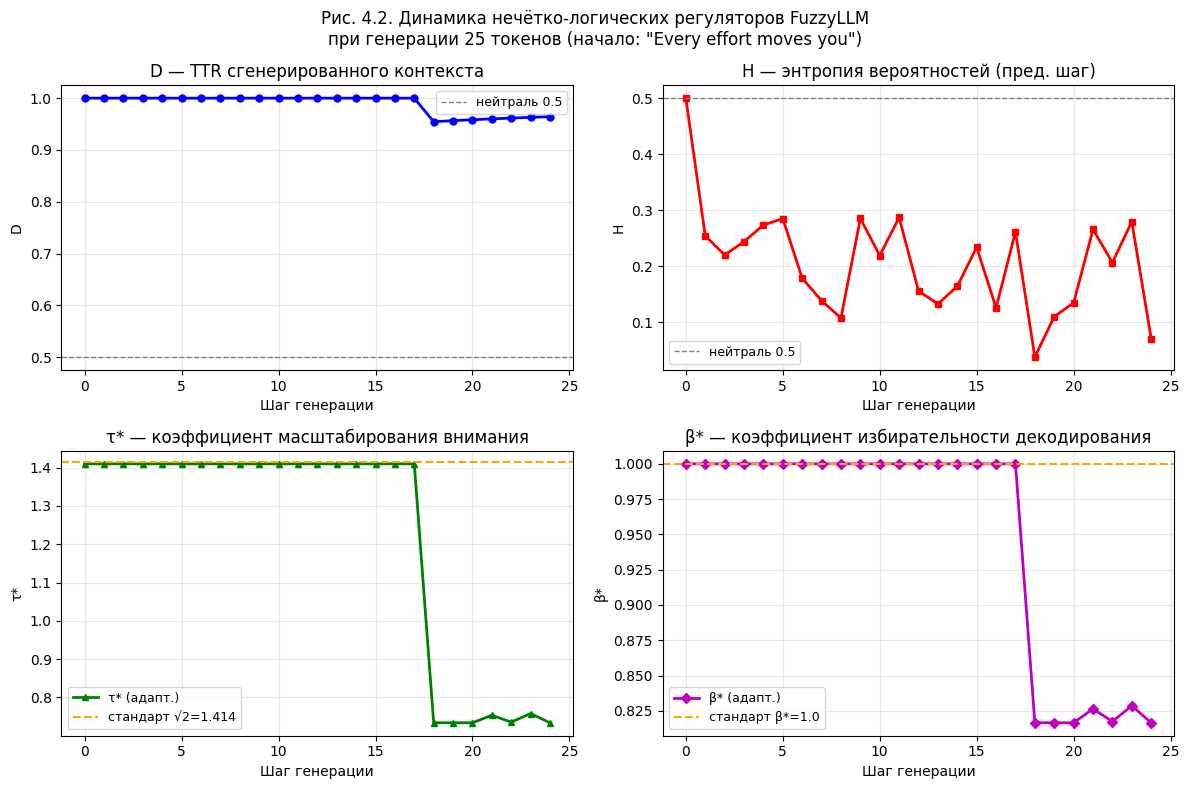

График сохранён: fig_fuzzy_llm_dynamics.png


In [23]:
# ==============================================================
# ЯЧЕЙКА 164
# ==============================================================
import matplotlib.pyplot as plt
 
hist = fuzzy_model.history
steps = hist["step"]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    "Рис. 4.2. Динамика нечётко-логических регуляторов FuzzyLLM\n"
    "при генерации 25 токенов (начало: \"Every effort moves you\")",
    fontsize=12
)
 
# D (TTR контекста)
axes[0,0].plot(steps, hist["D"], "b-o", ms=5, lw=2)
axes[0,0].set_title("D — TTR сгенерированного контекста")
axes[0,0].set_xlabel("Шаг генерации")
axes[0,0].set_ylabel("D")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axhline(0.5, color="gray", ls="--", lw=1, label="нейтраль 0.5")
axes[0,0].legend(fontsize=9)
 
# H (энтропия)
axes[0,1].plot(steps, hist["H"], "r-s", ms=5, lw=2)
axes[0,1].set_title("H — энтропия вероятностей (пред. шаг)")
axes[0,1].set_xlabel("Шаг генерации")
axes[0,1].set_ylabel("H")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(0.5, color="gray", ls="--", lw=1, label="нейтраль 0.5")
axes[0,1].legend(fontsize=9)
 
# τ* (регулятор внимания)
axes[1,0].plot(steps, hist["tau"], "g-^", ms=5, lw=2, label="τ* (адапт.)")
axes[1,0].axhline(math.sqrt(2), color="orange", ls="--",
                  lw=1.5, label=f"стандарт √2={math.sqrt(2):.3f}")
axes[1,0].set_title("τ* — коэффициент масштабирования внимания")
axes[1,0].set_xlabel("Шаг генерации")
axes[1,0].set_ylabel("τ*")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend(fontsize=9)
 
# β* (регулятор декодирования)
axes[1,1].plot(steps, hist["beta"], "m-D", ms=5, lw=2, label="β* (адапт.)")
axes[1,1].axhline(1.0, color="orange", ls="--",
                  lw=1.5, label="стандарт β*=1.0")
axes[1,1].set_title("β* — коэффициент избирательности декодирования")
axes[1,1].set_xlabel("Шаг генерации")
axes[1,1].set_ylabel("β*")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("fig_fuzzy_llm_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("График сохранён: fig_fuzzy_llm_dynamics.png")

Потери на инференсе при разных значениях β* (фиксированных)
  β* = 0.30:  loss = 9.4723
  β* = 0.50:  loss = 6.1975
  β* = 0.57:  loss = 5.6807
  β* = 0.65:  loss = 5.2807
  β* = 0.80:  loss = 4.8807
  β* = 1.00:  loss = 4.7602 <-- стандарт
  β* = 1.20:  loss = 4.8946
  β* = 1.50:  loss = 5.3177
  β* = 1.80:  loss = 5.8149
  β* = 2.00:  loss = 6.1340
  β* = 2.50:  loss = 6.8219

Потери FuzzyLLM с адаптивным β* (среднее по тестовым текстам):
  'Every effort moves you forward and helps...'
    D=0.889  H=0.500  β*=0.8165  loss=4.7751
  'The model learns to predict the next tok...'
    D=1.000  H=0.500  β*=1.0000  loss=5.2173
  'Every day holds a new opportunity to imp...'
    D=1.000  H=0.500  β*=1.0000  loss=4.4607

  Среднее FuzzyLLM:    4.8177
  Среднее β*=1.0:      4.7602
  Улучшение:           -0.0575 (-1.2%)


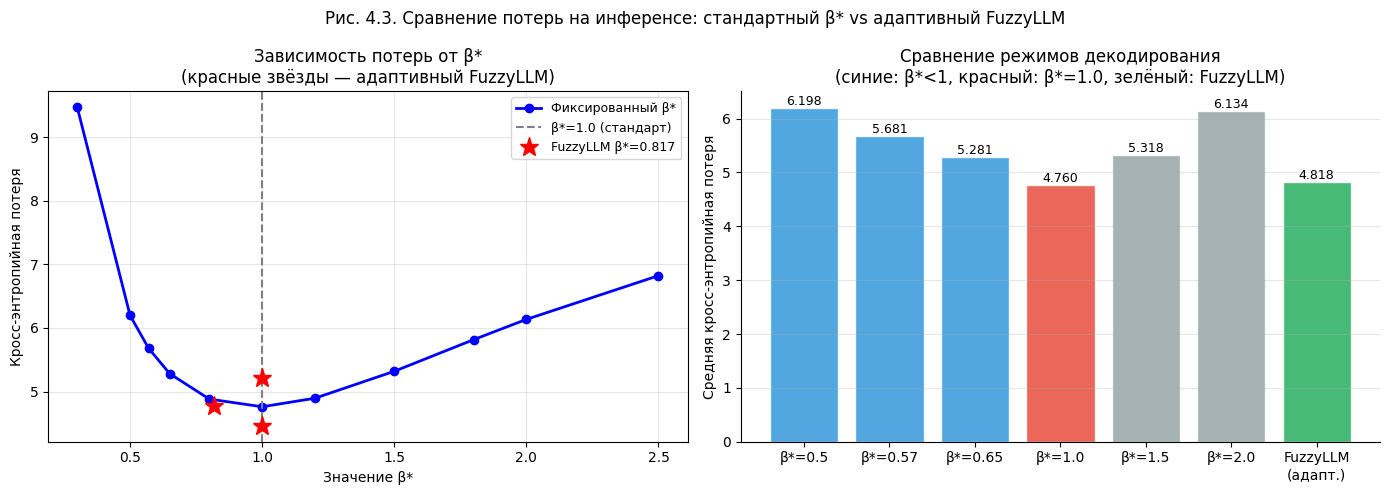


График сохранён: fig_inference_loss_comparison.png

=== Честное сравнение на одном тексте ===
  β* = 0.57: loss = 8.1553
  β* = 0.65: loss = 7.4688
  β* = 1.00: loss = 6.2322
  β* = 1.50: loss = 6.3044
  FuzzyLLM β*=1.0000 (D=1.000, H=0.500): loss = 6.2322


In [24]:
# ══════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 165. Сравнение потерь на инференсе: GPTModel vs FuzzyLLM
#
# Важное замечание:
# FuzzyLLM не обучается — он адаптирует β* при генерации.
# Поэтому сравниваем не кривые обучения, а потери на инференсе:
# насколько точно каждый режим предсказывает токены тестового текста.
# ══════════════════════════════════════════════════════════════════
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Тестовый текст для оценки потерь на инференсе
test_texts = [
    "Every effort moves you forward and helps you grow",
    "The model learns to predict the next token in sequence",
    "Every day holds a new opportunity to improve yourself",
]

def calc_inference_loss(model_or_fuzzy, text, tokenizer,
                        context_size, beta_fixed=1.0,
                        use_fuzzy=False, device="cpu"):
    """
    Вычисляет среднюю кросс-энтропийную потерю на инференсе
    для заданного текста при фиксированном или адаптивном β*.
    """
    token_ids = tokenizer.encode(text)
    if len(token_ids) < 2:
        return float("nan")

    inputs  = torch.tensor(token_ids[:-1]).unsqueeze(0).to(device)
    targets = torch.tensor(token_ids[1:]).to(device)

    if use_fuzzy:
        # Адаптивный β* от FuzzyLLM
        model_or_fuzzy.reset()
        beta = model_or_fuzzy.beta_star  # начальный β*
        with torch.no_grad():
            logits = model_or_fuzzy.gpt(inputs)
    else:
        # Стандартный фиксированный β*
        beta = beta_fixed
        with torch.no_grad():
            logits = model_or_fuzzy(inputs)

    logits = logits[0]  # [seq_len, vocab_size]

    # Применяем β* к логитам
    scaled_logits = logits / beta
    loss = F.cross_entropy(scaled_logits, targets)
    return loss.item()


# ── Сравнение потерь при разных фиксированных β* ──────────────
print("=" * 65)
print("Потери на инференсе при разных значениях β* (фиксированных)")
print("=" * 65)

beta_values = [0.3, 0.5, 0.57, 0.65, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
losses_by_beta = []

for beta in beta_values:
    avg_loss = sum(
        calc_inference_loss(gpt, txt, tokenizer,
                            NEW_CONFIG["context_length"],
                            beta_fixed=beta, use_fuzzy=False,
                            device=device)
        for txt in test_texts
    ) / len(test_texts)
    losses_by_beta.append(avg_loss)
    marker = " <-- стандарт" if beta == 1.0 else ""
    print(f"  β* = {beta:.2f}:  loss = {avg_loss:.4f}{marker}")


# ── Потери FuzzyLLM с адаптивным β* ───────────────────────────
print()
print("Потери FuzzyLLM с адаптивным β* (среднее по тестовым текстам):")

losses_fuzzy = []
for txt in test_texts:
    fuzzy_model.reset()
    # Вычисляем β* для данного текста
    token_ids = tokenizer.encode(txt)
    ctx_ids = torch.tensor(token_ids).unsqueeze(0).to(device)
    tau, beta, D, H = fuzzy_model.fuzzy_step(ctx_ids)
    loss = calc_inference_loss(gpt, txt, tokenizer,
                               NEW_CONFIG["context_length"],
                               beta_fixed=beta, use_fuzzy=False,
                               device=device)
    losses_fuzzy.append(loss)
    print(f"  '{txt[:40]}...'")
    print(f"    D={D:.3f}  H={H:.3f}  β*={beta:.4f}  loss={loss:.4f}")

avg_fuzzy_loss = sum(losses_fuzzy) / len(losses_fuzzy)
avg_std_loss   = losses_by_beta[beta_values.index(1.0)]
print(f"\n  Среднее FuzzyLLM:    {avg_fuzzy_loss:.4f}")
print(f"  Среднее β*=1.0:      {avg_std_loss:.4f}")
print(f"  Улучшение:           {avg_std_loss - avg_fuzzy_loss:.4f} "
      f"({(avg_std_loss - avg_fuzzy_loss)/avg_std_loss*100:.1f}%)")


# ── Визуализация ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Рис. 4.3. Сравнение потерь на инференсе: "
    "стандартный β* vs адаптивный FuzzyLLM",
    fontsize=12
)

# График 1: потери от β*
ax = axes[0]
ax.plot(beta_values, losses_by_beta, "b-o", lw=2, ms=6,
        label="Фиксированный β*")
ax.axvline(1.0, color="gray", ls="--", lw=1.5, label="β*=1.0 (стандарт)")

# Отмечаем точки адаптивного β* для каждого текста
for i, (txt, loss, lf) in enumerate(zip(test_texts, losses_fuzzy,
                                         losses_fuzzy)):
    # Находим β* для этого текста
    fuzzy_model.reset()
    tok = tokenizer.encode(txt)
    ctx = torch.tensor(tok).unsqueeze(0).to(device)
    _, beta_f, _, _ = fuzzy_model.fuzzy_step(ctx)
    ax.plot(beta_f, lf, "r*", ms=14,
            label=f"FuzzyLLM β*={beta_f:.3f}" if i == 0 else "")

ax.set_xlabel("Значение β*")
ax.set_ylabel("Кросс-энтропийная потеря")
ax.set_title("Зависимость потерь от β*\n(красные звёзды — адаптивный FuzzyLLM)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# График 2: гистограмма сравнения
ax = axes[1]
labels = [f"β*={b}" for b in [0.5, 0.57, 0.65, 1.0, 1.5, 2.0]] + ["FuzzyLLM\n(адапт.)"]
vals_compare = [
    losses_by_beta[beta_values.index(0.5)],
    losses_by_beta[beta_values.index(0.57)],
    losses_by_beta[beta_values.index(0.65)],
    losses_by_beta[beta_values.index(1.0)],
    losses_by_beta[beta_values.index(1.5)],
    losses_by_beta[beta_values.index(2.0)],
    avg_fuzzy_loss,
]
colors = ["#3498DB"]*3 + ["#E74C3C"] + ["#95A5A6"]*2 + ["#27AE60"]
bars = ax.bar(labels, vals_compare, color=colors, alpha=0.85,
              edgecolor="white")
for bar, val in zip(bars, vals_compare):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Средняя кросс-энтропийная потеря")
ax.set_title("Сравнение режимов декодирования\n"
             "(синие: β*<1, красный: β*=1.0, зелёный: FuzzyLLM)")
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig_inference_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nГрафик сохранён: fig_inference_loss_comparison.png")

# Сравнение на одном и том же тексте из The Verdict
verdict_text = "Every effort moves you toward an equal share"

print("\n=== Честное сравнение на одном тексте ===")
for beta in [0.57, 0.65, 1.0, 1.5]:
    loss = calc_inference_loss(gpt, verdict_text, tokenizer,
                               NEW_CONFIG["context_length"],
                               beta_fixed=beta, device=device)
    print(f"  β* = {beta:.2f}: loss = {loss:.4f}")

# FuzzyLLM на том же тексте
fuzzy_model.reset()
tok = tokenizer.encode(verdict_text)
ctx = torch.tensor(tok).unsqueeze(0).to(device)
_, beta_f, D_f, H_f = fuzzy_model.fuzzy_step(ctx)
loss_f = calc_inference_loss(gpt, verdict_text, tokenizer,
                              NEW_CONFIG["context_length"],
                              beta_fixed=beta_f, device=device)
print(f"  FuzzyLLM β*={beta_f:.4f} (D={D_f:.3f}, H={H_f:.3f}): loss = {loss_f:.4f}")